In [10]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import json

In [11]:
import pandas as pd
import numpy as np
from glob import glob
from sklearn.decomposition import TruncatedSVD

In [12]:
songs_with_labels = tf.io.gfile.glob(
    "/home/georgios/Music Analysis/creating_spectrogram_batches/train_songs.json"
)

In [13]:
with open(songs_with_labels[-1], 'r') as f:
    songs_labels = json.loads(f.read())

In [42]:
labels = list(songs_labels.values())
labels[:5]

[[0, 0, 0, 1, 0, 0, 0, 0],
 [0, 0, 0, 1, 0, 0, 1, 0],
 [0, 0, 0, 0, 0, 1, 1, 0],
 [0, 0, 1, 1, 0, 0, 0, 0],
 [0, 0, 1, 1, 1, 0, 1, 0]]

In [25]:
def prepare_svd_from_songs(labels_dataset, n_components):
  
    all_labels = np.array(labels_dataset)
    
    # fit SVD
    svd = TruncatedSVD(n_components=n_components)
    svd.fit(all_labels)

    print("Variance explained by each SVD component:", svd.explained_variance_ratio_)
    print("Total variance explained by SVD:", svd.explained_variance_ratio_.sum())
    
    # Convert components to TensorFlow constant
    svd_components = tf.constant(svd.components_, dtype=tf.float32)
    
    return svd_components

In [36]:
svd_transformation_6 = prepare_svd_from_songs(labels, 6)
np.save('npy/svd_components_6', svd_transformation_6.numpy())

Variance explained by each SVD component: [0.10941789 0.27066491 0.20767833 0.14066182 0.08704472 0.07954318]
Total variance explained by SVD: 0.8950108347373055


In [37]:
svd_transformation_7 = prepare_svd_from_songs(labels, 7)
np.save('npy/svd_components_7', svd_transformation_7.numpy())

Variance explained by each SVD component: [0.10941789 0.27066491 0.20767833 0.14066182 0.08704472 0.07954318
 0.0711917 ]
Total variance explained by SVD: 0.9662025392981941


In [38]:
import pandas as pd

components = np.load("npy/svd_components_6.npy")  # shape: [6, 8]
genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']
pd.DataFrame(components, columns=genre_names)

,LAIKO,REMPETIKO,ENTEXNO,ROCK,Mod LAIKO,POP,ENALLAKTIKO,HIPHOP/RNB
0,0.680004,0.118935,0.479694,0.148991,0.480384,0.099550,0.174370,0.007781
1,-0.447311,-0.140251,0.455443,0.494557,-0.164691,0.166731,0.521415,0.037831
2,-0.349326,-0.205085,-0.335488,-0.009074,0.783903,0.316120,0.091862,0.020065
3,-0.298029,-0.336401,0.625452,-0.291524,0.192318,-0.225383,-0.477520,-0.077634
4,0.065060,-0.207934,-0.207108,0.694627,0.157935,-0.579465,-0.235249,-0.105189
5,-0.281771,0.784017,0.121399,0.270878,0.112560,0.178463,-0.410153,-0.071178


In [39]:
components = np.load("npy/svd_components_7.npy")
pd.DataFrame(components, columns=genre_names)

,LAIKO,REMPETIKO,ENTEXNO,ROCK,Mod LAIKO,POP,ENALLAKTIKO,HIPHOP/RNB
0,0.680004,0.118935,0.479694,0.148991,0.480384,0.099550,0.174370,0.007781
1,-0.447311,-0.140251,0.455443,0.494557,-0.164691,0.166731,0.521415,0.037831
2,-0.349326,-0.205085,-0.335488,-0.009074,0.783903,0.316120,0.091862,0.020065
3,-0.298029,-0.336401,0.625452,-0.291524,0.192318,-0.225383,-0.477520,-0.077634
4,0.065060,-0.207934,-0.207108,0.694627,0.157935,-0.579465,-0.235249,-0.105189
5,-0.281771,0.784017,0.121399,0.270878,0.112560,0.178463,-0.410153,-0.071178
6,0.206846,-0.391014,-0.025376,0.298917,-0.228964,0.662297,-0.472382,-0.011007


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load saved components and label matrix
svd_components = np.load("npy/svd_components_7.npy")
labels = np.array(labels)

# Project each song into SVD space: [num_songs, 7]
song_embeddings = np.matmul(labels, svd_components.T)

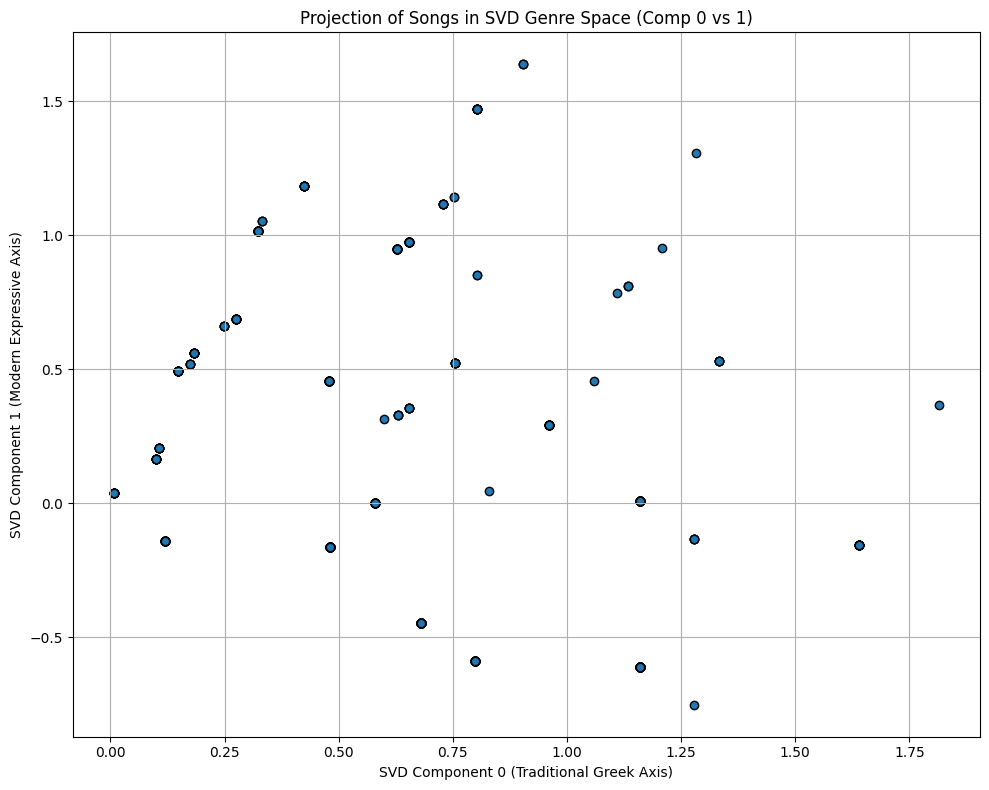

In [54]:
plt.figure(figsize=(10, 8))
plt.scatter(song_embeddings[:, 0], song_embeddings[:, 1], alpha=0.99, edgecolor='k')
plt.xlabel("SVD Component 0 (Traditional Greek Axis)")
plt.ylabel("SVD Component 1 (Modern Expressive Axis)")
plt.title("Projection of Songs in SVD Genre Space (Comp 0 vs 1)")
plt.grid(True)
plt.tight_layout()
plt.show();

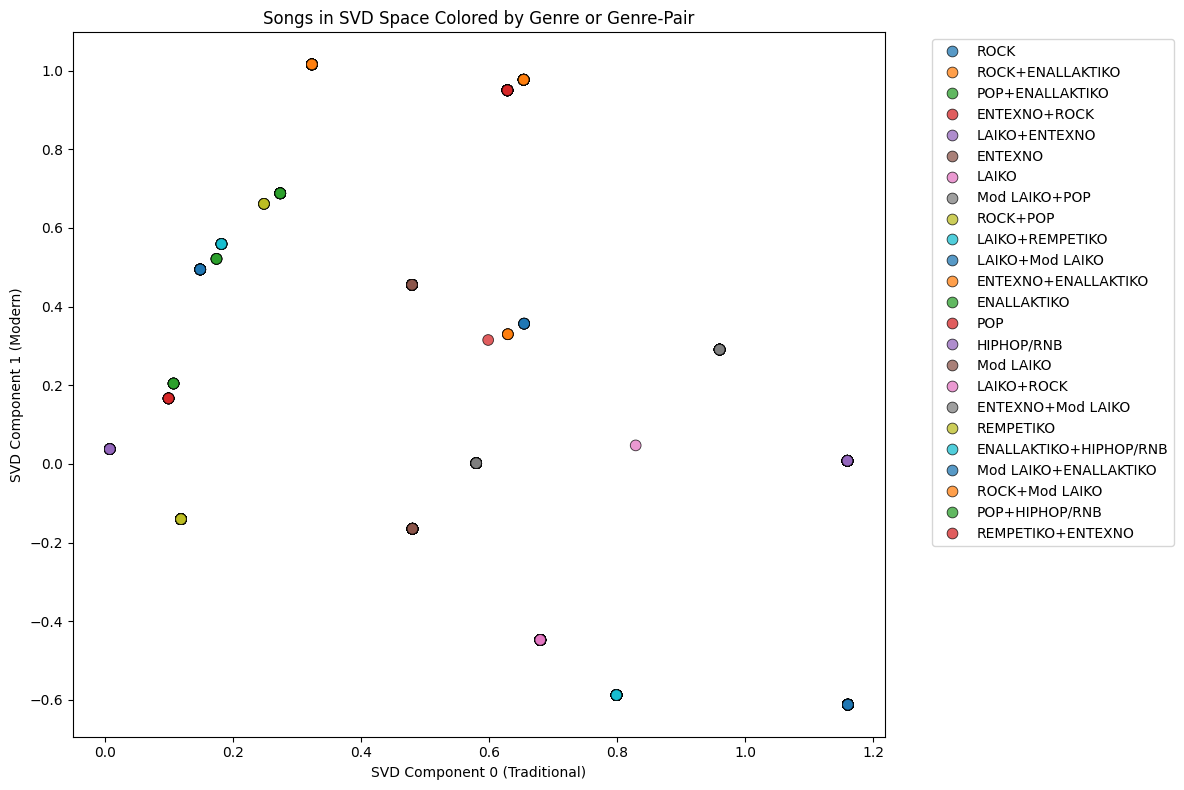

In [69]:
genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']

# Create genre label per song — e.g. combinations like 'ROCK+ENALLAKTIKO'
def label_combination(row):
    genres = [genre_names[i] for i, val in enumerate(row) if val == 1]
    return '+'.join(genres) if genres else 'None'

song_labels = [label_combination(row) for row in labels]

# keep only songs with exactly 1 or 2 genres (cleaner projection)
filtered_mask = [(s.count('+') <= 1) for s in song_labels]
filtered_embeddings = song_embeddings[filtered_mask]
filtered_labels = np.array(song_labels)[filtered_mask]

# Plot with seaborn
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=filtered_embeddings[:, 0],
    y=filtered_embeddings[:, 1],
    hue=filtered_labels,
    palette="tab10",
    s=60,
    alpha=0.75,
    edgecolor='k'
)
plt.xlabel("SVD Component 0 (Traditional)")
plt.ylabel("SVD Component 1 (Modern)")
plt.title("Songs in SVD Space Colored by Genre or Genre-Pair")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();